## Rutendra Biswal_Capstone_Project

In [ ]:
#!pip install pyforest

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
file_path = "Bank_Stability_Dataset.csv"
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Bank_Name,Year,Quarter,Capital_Adequacy_Ratio,Non_Performing_Loans_Ratio,Liquidity_Coverage_Ratio,Return_on_Assets,Loan_to_Deposit_Ratio,Net_Interest_Margin,Operational_Efficiency_Ratio,Went_Defunct
0,Central Mountain Bank,2000,1,6.99,6.59,76.48,0.52,96.49,0.88,95.79,Yes
1,First Mountain Bank,2000,1,13.53,1.53,125.43,1.77,65.34,3.12,30.87,No
2,United River Trust,2000,1,8.55,1.44,109.87,2.16,60.92,2.29,64.66,No
3,National State Bancorp,2000,1,11.55,2.07,105.75,1.73,71.11,2.42,53.76,No
4,National Coast Financial,2000,1,4.80,6.12,63.98,0.85,99.80,0.47,88.23,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Bank_Name                     5000 non-null   object 
 1   Year                          5000 non-null   int64  
 2   Quarter                       5000 non-null   int64  
 3   Capital_Adequacy_Ratio        5000 non-null   float64
 4   Non_Performing_Loans_Ratio    5000 non-null   float64
 5   Liquidity_Coverage_Ratio      5000 non-null   float64
 6   Return_on_Assets              5000 non-null   float64
 7   Loan_to_Deposit_Ratio         5000 non-null   float64
 8   Net_Interest_Margin           5000 non-null   float64
 9   Operational_Efficiency_Ratio  5000 non-null   float64
 10  Went_Defunct                  4975 non-null   object 
dtypes: float64(7), int64(2), object(2)
memory usage: 429.8+ KB


In [ ]:
df.shape

(5000, 11)

In [ ]:
df.describe()

,Year,Quarter,Capital_Adequacy_Ratio,Non_Performing_Loans_Ratio,Liquidity_Coverage_Ratio,Return_on_Assets,Loan_to_Deposit_Ratio,Net_Interest_Margin,Operational_Efficiency_Ratio
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2012.000000,2.500000,10.784664,3.042464,109.926224,1.388390,75.721078,2.599438,56.170966
std,7.211824,1.118146,3.114664,2.594853,22.604021,1.366573,16.352177,0.938212,15.692040
min,2000.000000,1.000000,0.000000,0.000000,39.170000,-4.660000,31.440000,0.000000,15.050000
25%,2006.000000,1.750000,9.190000,1.490000,104.427500,1.230000,64.737500,2.237500,45.220000
50%,2012.000000,2.500000,11.380000,2.290000,116.930000,1.830000,72.590000,2.840000,53.220000
75%,2018.000000,3.250000,12.920000,3.400000,125.052500,2.240000,82.927500,3.240000,64.782500
max,2024.000000,4.000000,19.880000,15.090000,156.790000,3.760000,142.980000,4.690000,118.530000


In [ ]:
#Check for missing values
print(df.isnull().sum())

Bank_Name                        0
Year                             0
Quarter                          0
Capital_Adequacy_Ratio           0
Non_Performing_Loans_Ratio       0
Liquidity_Coverage_Ratio         0
Return_on_Assets                 0
Loan_to_Deposit_Ratio            0
Net_Interest_Margin              0
Operational_Efficiency_Ratio     0
Went_Defunct                    25
dtype: int64


#Cleaning

In [ ]:
# Step 2: Data Cleaning
# # Assuming df is your DataFrame
mode_value = df['Went_Defunct'].mode()[0]  # Get the mode of the Went_Defunct column
df['Went_Defunct'].fillna(mode_value, inplace=True)  # Fill NaN values with the mode

<ipython-input-10-7bf049e6dfcb>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Went_Defunct'].fillna(mode_value, inplace=True)  # Fill NaN values with the mode


In [ ]:
df_clean = df['Went_Defunct'].mode()[0]  # Get the first mode value


In [ ]:
# df_clean= df.dropna(subset=['Went_Defunct'])
mode_value = df['Went_Defunct'].mode()[0]  # Get the mode of the Went_Defunct column
df['Went_Defunct'].fillna(mode_value, inplace=True)  # Fill NaN values with the mode
df_clean = df  # Assign the modified DataFrame to df_clean
df_clean.shape

(5000, 11)

In [ ]:
df_clean.isnull().sum()

,0
Bank_Name,0
Year,0
Quarter,0
Capital_Adequacy_Ratio,0
Non_Performing_Loans_Ratio,0
Liquidity_Coverage_Ratio,0
Return_on_Assets,0
Loan_to_Deposit_Ratio,0
Net_Interest_Margin,0
Operational_Efficiency_Ratio,0


In [ ]:
df_clean= df_clean.drop_duplicates()
print(df_clean['Went_Defunct'].value_counts())

Went_Defunct
No     4000
Yes    1000
Name: count, dtype: int64


In [ ]:
# Step 3: Encode the target variable 'Went_Defunct'-{"yes":1,"NO"-0}

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_clean['Went_Defunct'] = label_encoder.fit_transform(df_clean['Went_Defunct'])

# EDA

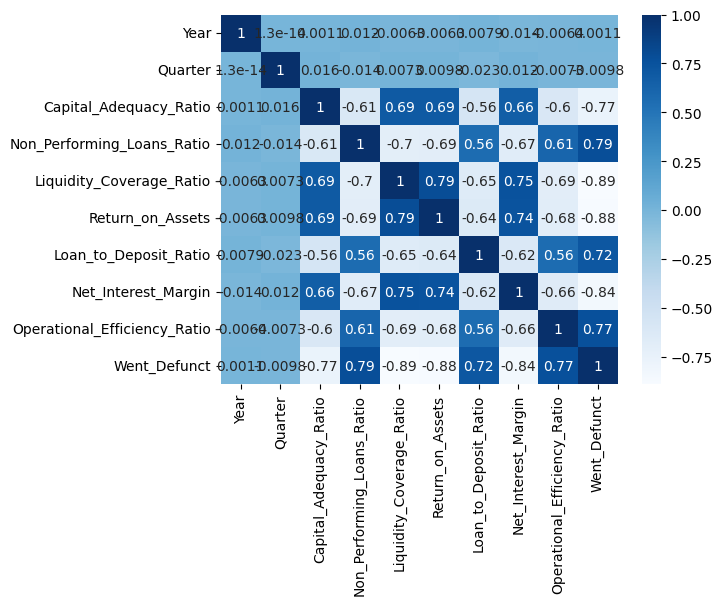

In [ ]:
#heat map
correlation = df_clean.select_dtypes(include=["int","float"]).corr()
sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns,cmap="Blues", annot=True)
plt.show()

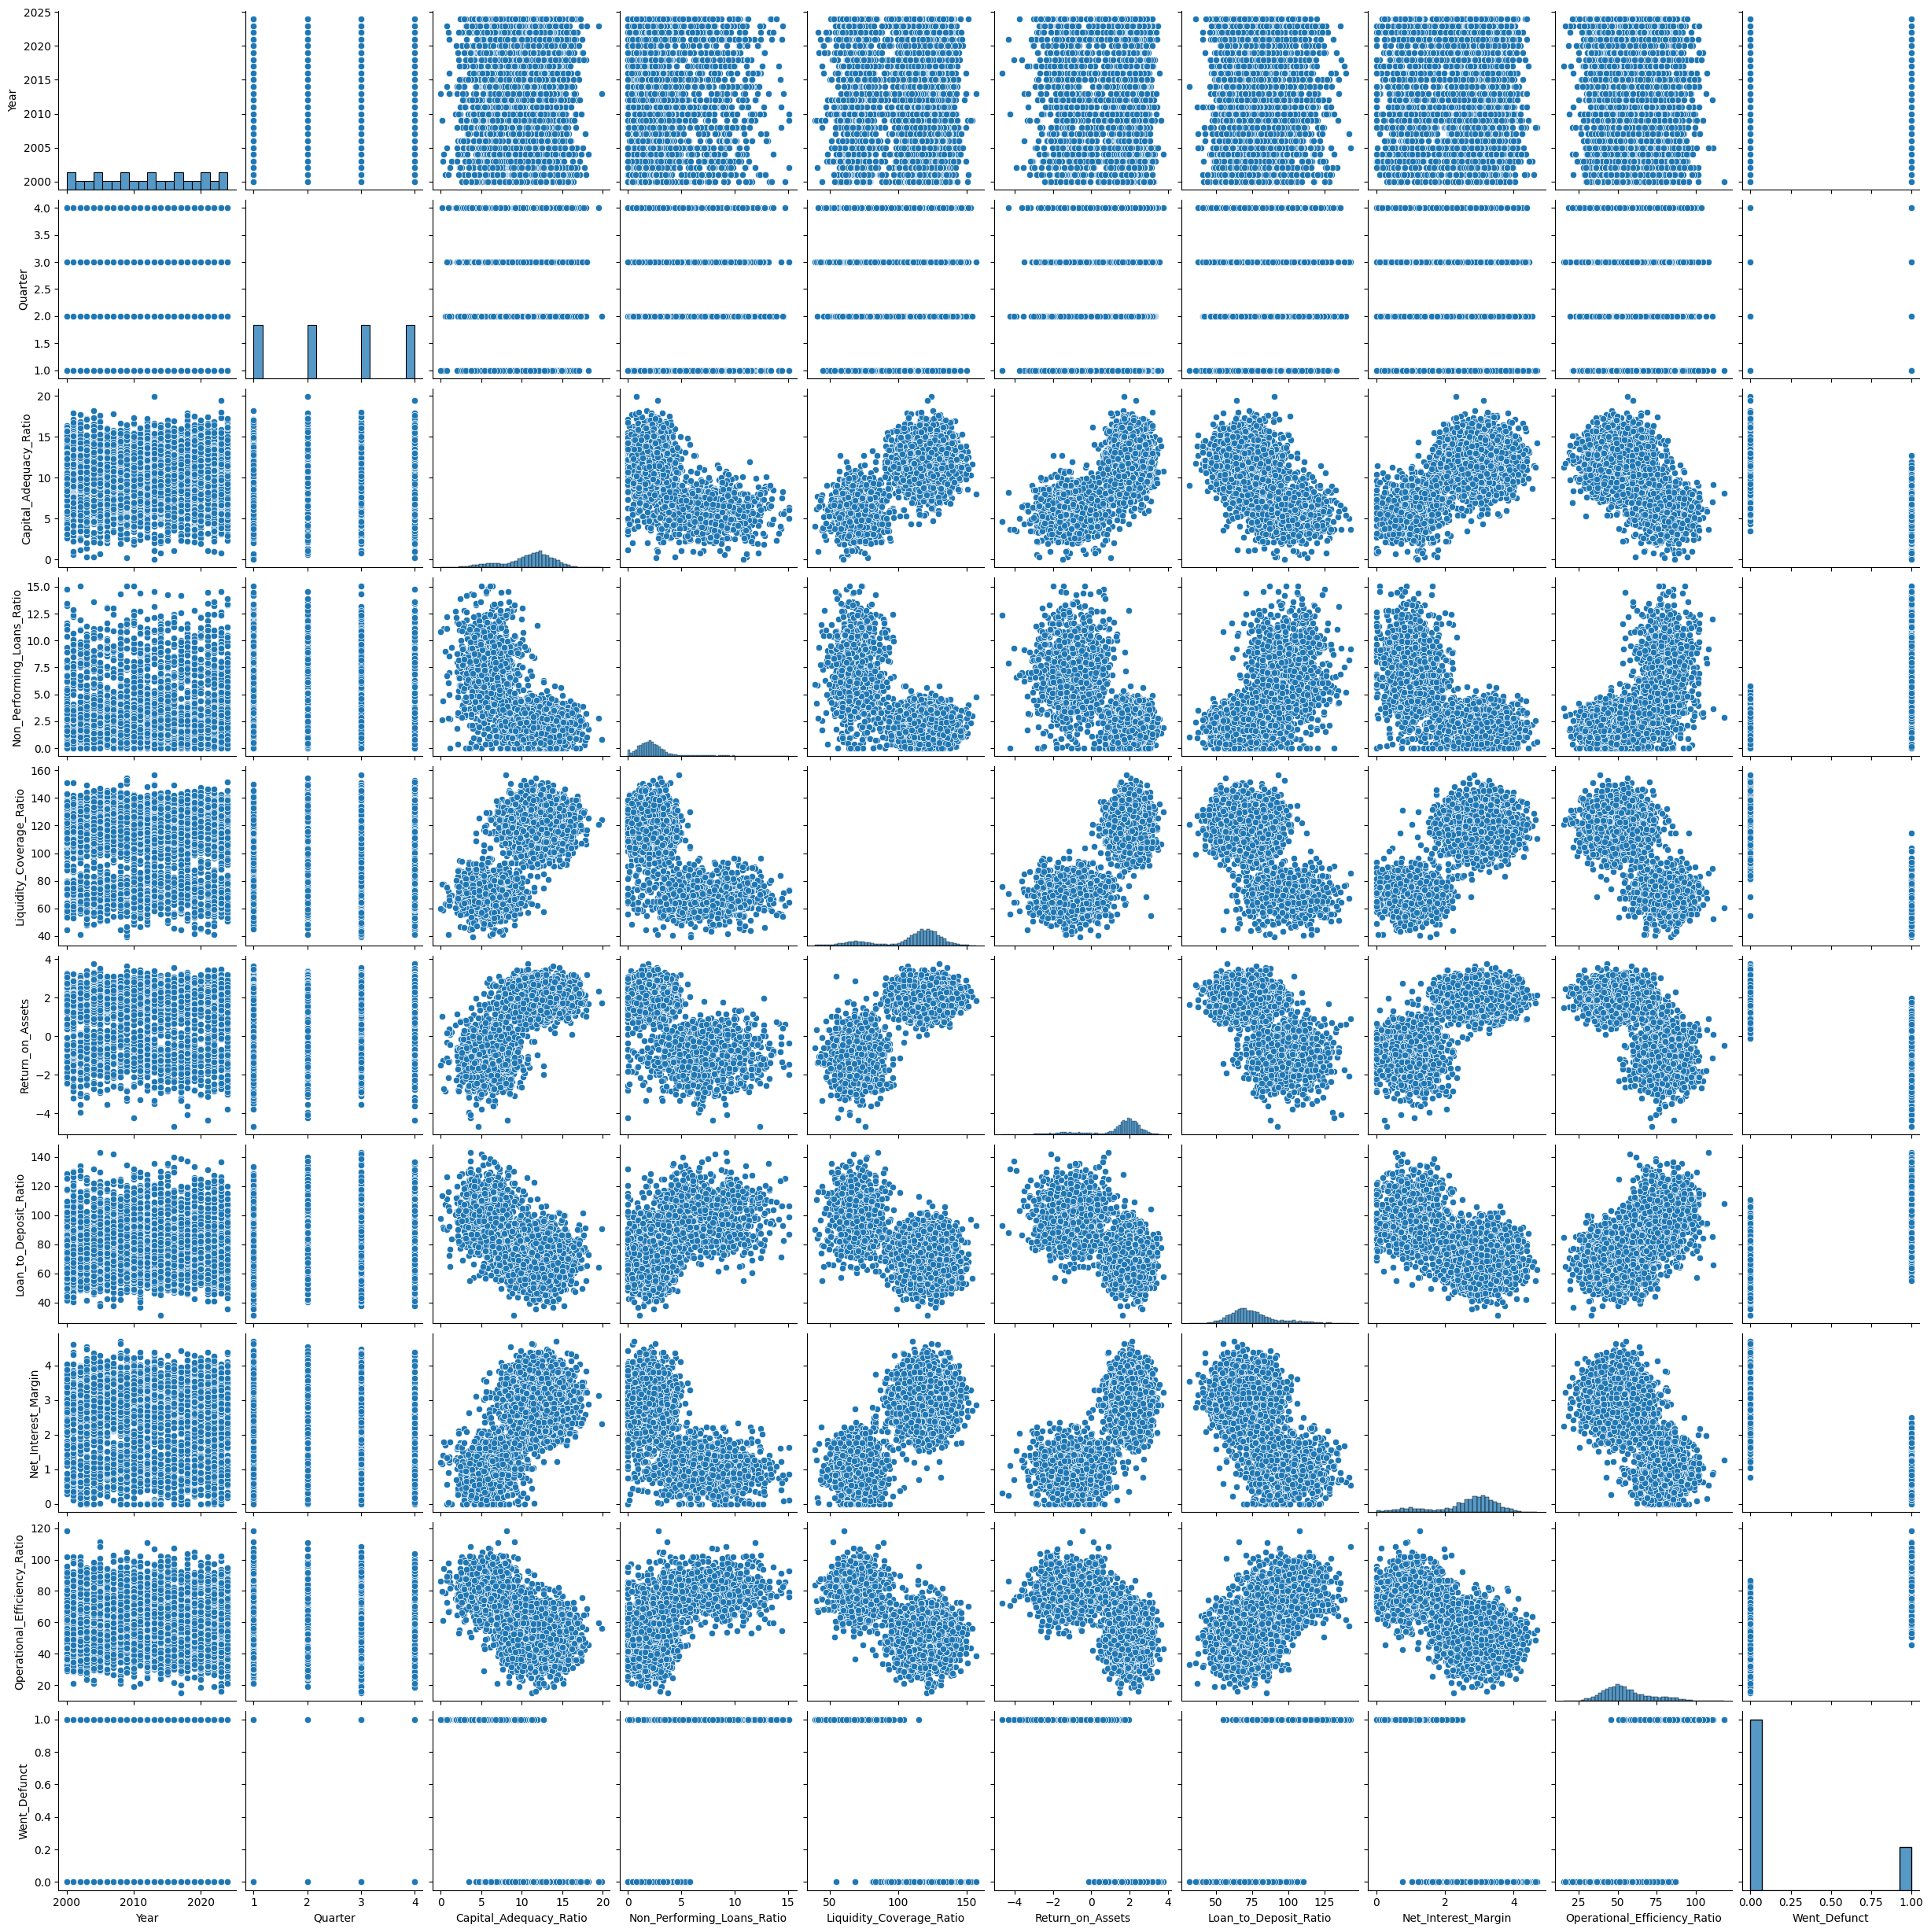

In [ ]:
#scatter plot
sns.pairplot(df_clean)

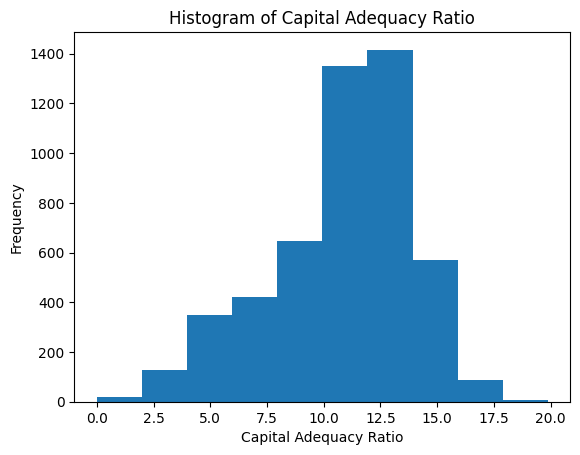

In [ ]:
#Histogram of CAR
plt.hist(df_clean['Capital_Adequacy_Ratio'], bins=10)
plt.xlabel('Capital Adequacy Ratio')
plt.ylabel('Frequency')
plt.title('Histogram of Capital Adequacy Ratio')
plt.show()

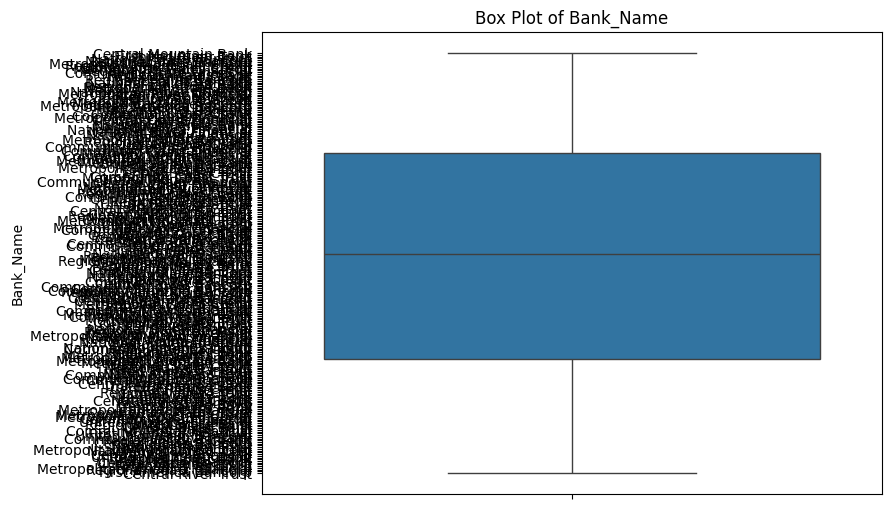

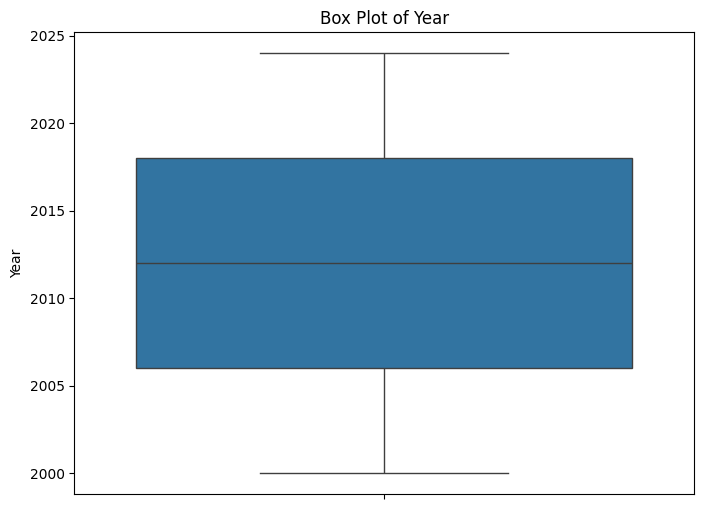

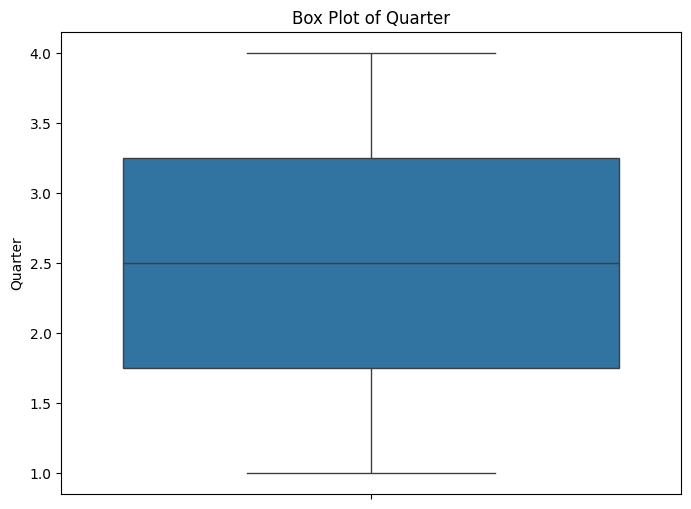

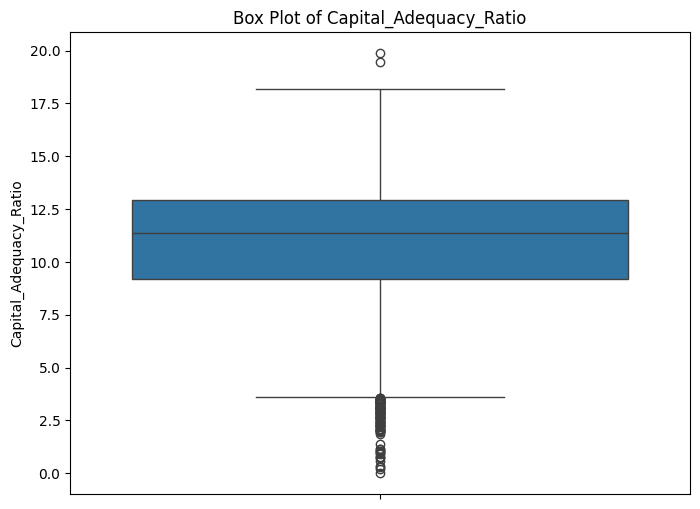

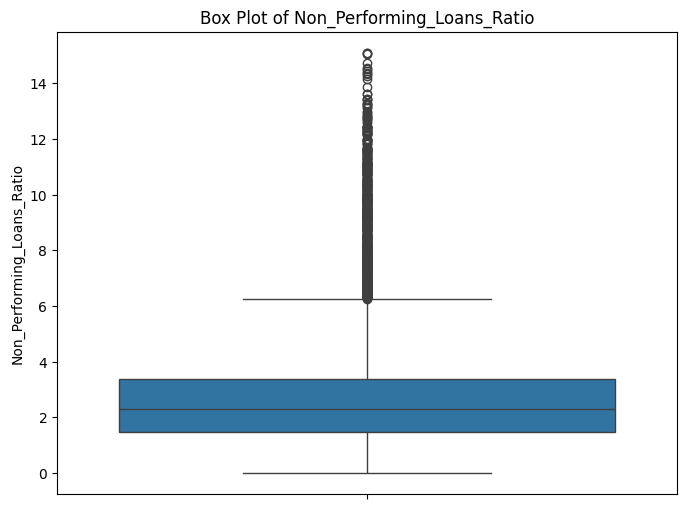

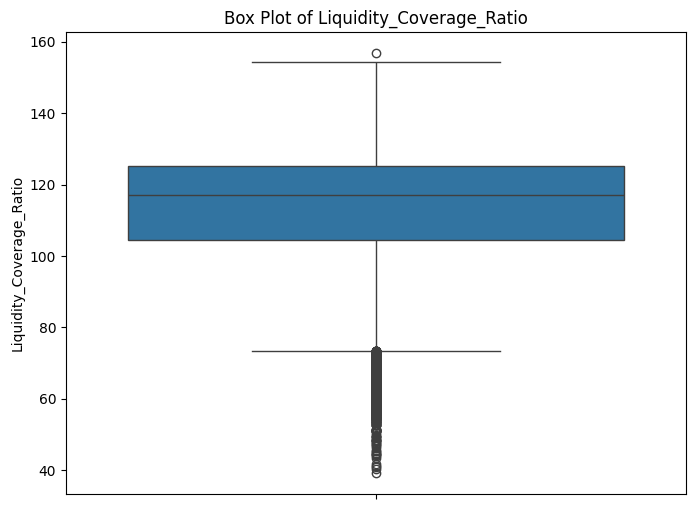

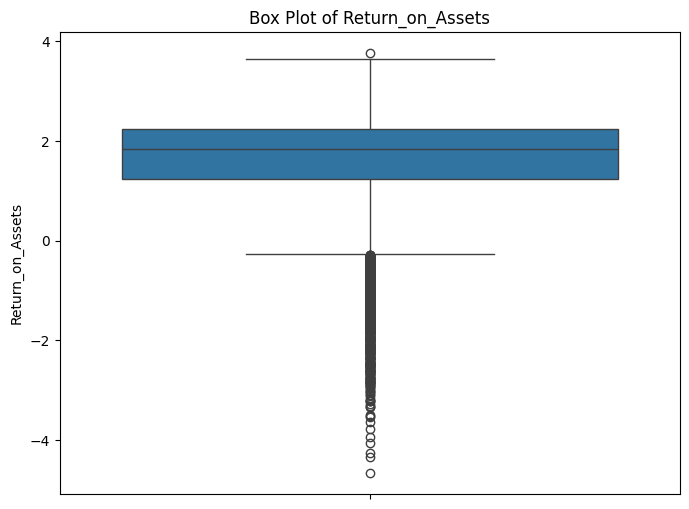

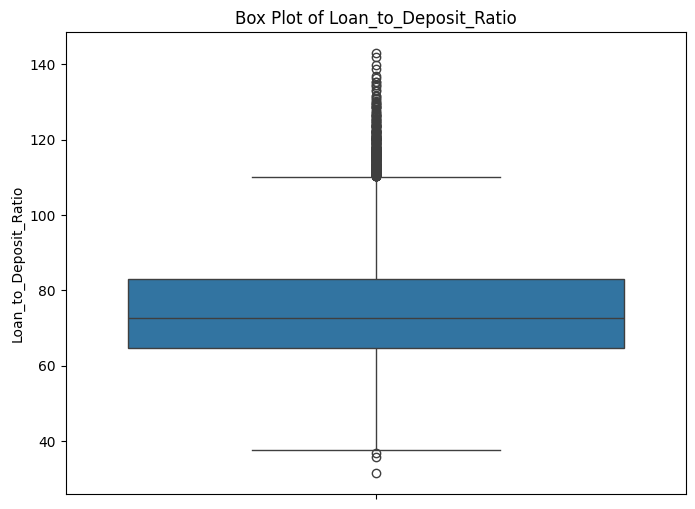

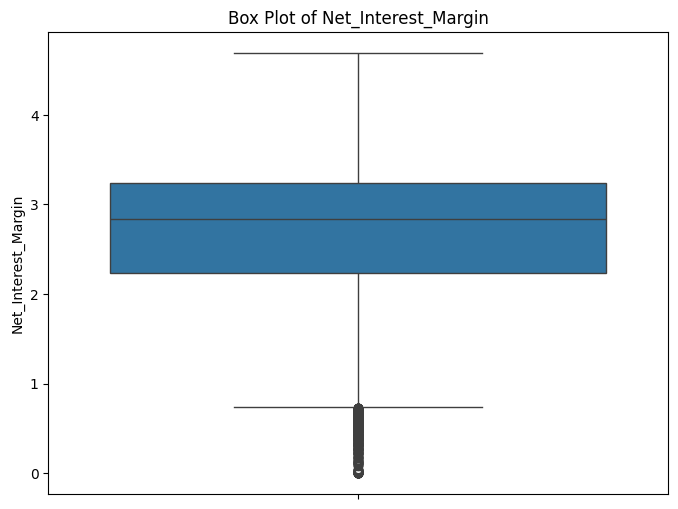

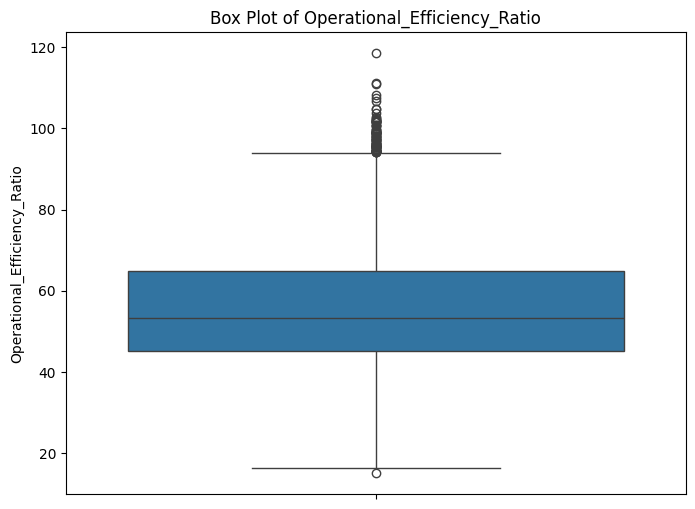

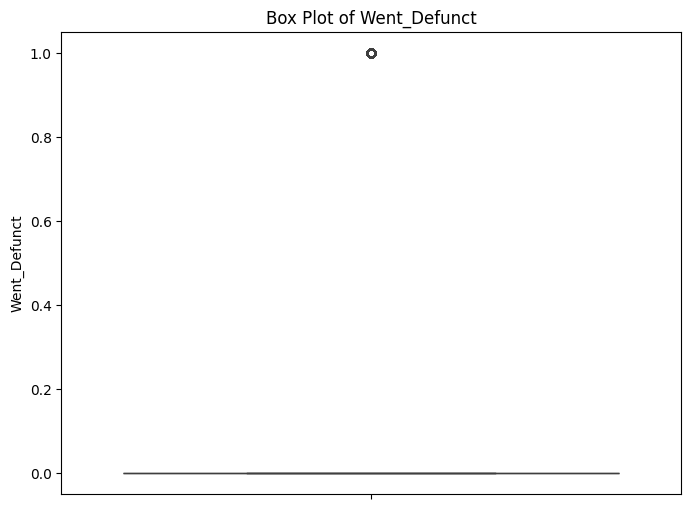

In [ ]:

# Loop through each column and create a box plot
for column in df_clean.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df_clean[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)
    plt.show()


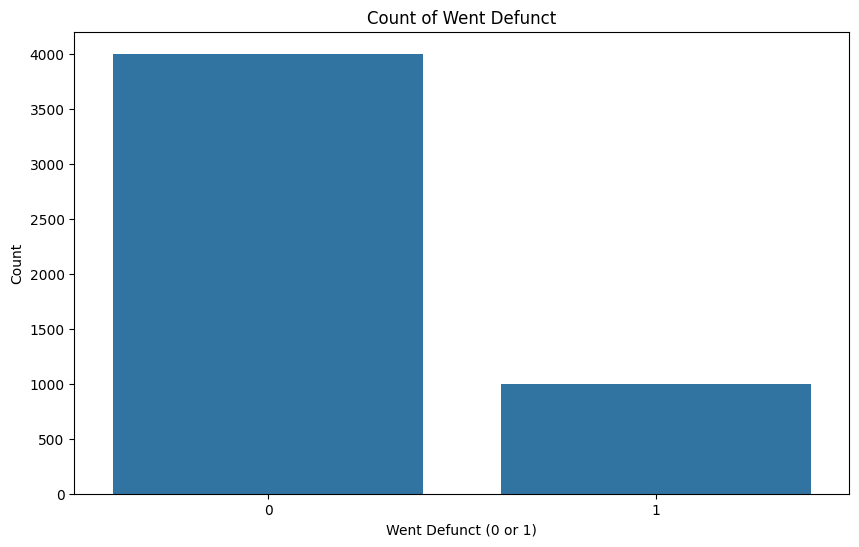

In [ ]:
# Create the countplot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.countplot(x='Went_Defunct', data=df_clean)
plt.title('Count of Went Defunct')
plt.xlabel('Went Defunct (0 or 1)')
plt.ylabel('Count')
plt.show()

Text(0.5, 1.0, 'Liquidity Ratio by Stability')

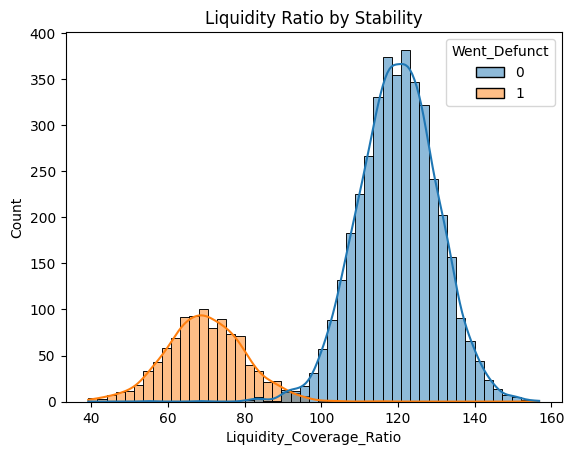

In [ ]:
sns.histplot(data=df_clean, x='Liquidity_Coverage_Ratio', hue='Went_Defunct', kde=True)
plt.title("Liquidity Ratio Distribution by Bank StabiLity")
plt. title("Liquidity Ratio by Stability")

#ML


In [ ]:
#to find categorical columns and numerical columns
categorial_col = [col for col in df_clean.columns if df_clean[col].dtype == 'object']

numerical_col = [col for col in df_clean.columns if df_clean[col].dtype != 'object']
print('Categorical columns :',categorial_col)
print('Numerical columns :',numerical_col)

Categorical columns : ['Bank_Name']
Numerical columns : ['Year', 'Quarter', 'Capital_Adequacy_Ratio', 'Non_Performing_Loans_Ratio', 'Liquidity_Coverage_Ratio', 'Return_on_Assets', 'Loan_to_Deposit_Ratio', 'Net_Interest_Margin', 'Operational_Efficiency_Ratio', 'Went_Defunct']


#Out-layer removal

In [ ]:
#z-score
def remove_outliers_zscore(df, columns, threshold=3):
    """Remove outliers using the Z-score method."""
    z = np.abs((df[columns] - df[columns].mean()) / df[columns].std())
    df_filtered = df[(z < threshold).all(axis=1)]
    return df_filtered

In [ ]:
# Assuming numerical_col is defined somewhere
numerical_col = ['Capital_Adequacy_Ratio', 'Non_Performing_Loans_Ratio', 'Liquidity_Coverage_Ratio',
                 'Return_on_Assets', 'Loan_to_Deposit_Ratio', 'Net_Interest_Margin',
                 'Operational_Efficiency_Ratio']

In [ ]:
# Remove outliers using the Z-score method
bank_cleaned_zscore = remove_outliers_zscore(df_clean, numerical_col)

In [ ]:
# Check the shape of the cleaned dataset after Z-score
original_shape = df_clean.shape
cleaned_shape_zscore = bank_cleaned_zscore.shape
print("Original Shape:", original_shape)
print("Shape after Z-score Outlier Removal:", cleaned_shape_zscore)

Original Shape: (5000, 11)
Shape after Z-score Outlier Removal: (4777, 11)


In [ ]:
# Assuming 'df_clean' is your DataFrame
# Separate features (X) and target (y)
X = df_clean.drop('Went_Defunct', axis=1)
y = df_clean['Went_Defunct']

#Level Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Apply Label Encoding to categorical features
label_encoders = {}

for column in X.select_dtypes(include=['category', 'object']).columns:
    label_encoders[column] = LabelEncoder()
    X[column] = label_encoders[column].fit_transform(X[column])

#Train-Test

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

##Random forest

In [ ]:
# Initialize and train a Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_y_pred = rf_clf.predict(X_test)
X_train.shape

(4000, 10)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print(f"Random Forest Accuracy: {rf_accuracy}")


Random Forest Accuracy: 0.999


In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix

m = confusion_matrix(y_test,rf_y_pred)
print (m)
print ("Accuracy of prediction:", 100*round((m[0,0]+m[1,1]) / m.sum(),3),"%")

[[793   1]
 [  0 206]]
Accuracy of prediction: 99.9 %


##Logistic regression

In [ ]:
#logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
# Create a logistic regression model with class weights
model = LogisticRegression(class_weight={0: 60, 1: 1}, solver='liblinear', max_iter=1000)

In [ ]:
# Train the model
model.fit(X_train, y_train)

LogisticRegression(class_weight={0: 60, 1: 1}, max_iter=1000,
                   solver='liblinear')

In [ ]:
# Predict on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       794
           1       1.00      0.86      0.93       206

    accuracy                           0.97      1000
   macro avg       0.98      0.93      0.95      1000
weighted avg       0.97      0.97      0.97      1000



In [ ]:
# Print ROC AUC Score
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

ROC AUC Score: 0.9999816585556723


In [ ]:
import pickle

In [ ]:
#Download the ppickle file of Logistic regression
with open ("logistic_model.pkl", "wb") as f:
 pickle.dump (model, f)

In [ ]:
##Download the ppickle file of Random-Forest

with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_clf, f)

In [ ]:
with open("bank_name.pkl", "wb") as f:
    pickle.dump(df_clean, f)